In [1]:
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [6]:
# Simple RNN for simple sinusoidal data

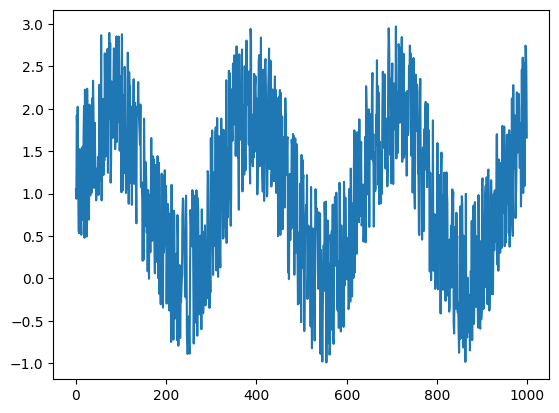

In [2]:
# convert data vector into matrix
def convertToMatrix(data, step):
    X, Y = [], []
    for i in range(len(data)-step):
        d = i+step; X.append(data[i:d,]); Y.append(data[d,])
    return np.array(X), np.array(Y)
    
step = 4; N = 1000; Tp = 800; t = np.arange(0,N)
x = np.sin(0.02*t) + 2*np.random.rand(N)
df = pd.DataFrame(x)
df.head()

plt.plot(df)
plt.show()

values = df.values
train, test = values[0:Tp,:], values[Tp:N,:]
# add step elements into train and test
test = np.append(test,np.repeat(test[-1,],step))
train = np.append(train,np.repeat(train[-1,],step))

In [3]:
trainX, trainY = convertToMatrix(train,step)
testX, testY = convertToMatrix(test,step)
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

model = Sequential()
model.add(SimpleRNN(units=32, input_shape=(1,step), activation="relu"))
model.add(Dense(8, activation="relu"));
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='rmsprop')
model.summary()

C:\Users\WBS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,457 (5.69 KB)

 Trainable params: 1,457 (5.69 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.fit(trainX, trainY, epochs=100, batch_size=16, verbose=2)

Epoch 1/100
50/50 - 3s - 51ms/step - loss: 0.9201
Epoch 2/100
50/50 - 0s - 5ms/step - loss: 0.4102
Epoch 3/100
50/50 - 0s - 7ms/step - loss: 0.4000
Epoch 4/100
50/50 - 0s - 6ms/step - loss: 0.3934
Epoch 5/100
50/50 - 0s - 4ms/step - loss: 0.3936
Epoch 6/100
50/50 - 0s - 4ms/step - loss: 0.3913
Epoch 7/100
50/50 - 0s - 4ms/step - loss: 0.3893
Epoch 8/100
50/50 - 0s - 4ms/step - loss: 0.3872
Epoch 9/100
50/50 - 0s - 4ms/step - loss: 0.3858
Epoch 10/100
50/50 - 0s - 4ms/step - loss: 0.3863
Epoch 11/100
50/50 - 0s - 6ms/step - loss: 0.3844
Epoch 12/100
50/50 - 0s - 5ms/step - loss: 0.3834
Epoch 13/100
50/50 - 0s - 4ms/step - loss: 0.3829
Epoch 14/100
50/50 - 0s - 8ms/step - loss: 0.3822
Epoch 15/100
50/50 - 0s - 5ms/step - loss: 0.3828
Epoch 16/100
50/50 - 0s - 8ms/step - loss: 0.3834
Epoch 17/100
50/50 - 0s - 4ms/step - loss: 0.3811
Epoch 18/100
50/50 - 0s - 8ms/step - loss: 0.3814
Epoch 19/100
50/50 - 0s - 4ms/step - loss: 0.3821
Epoch 20/100
50/50 - 0s - 4ms/step - loss: 0.3793
Epoch 21

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
0.3532641530036926


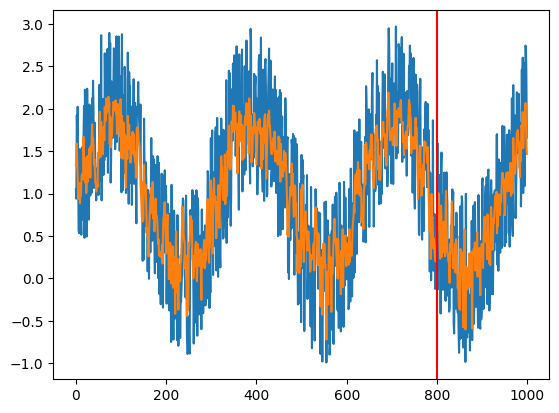

In [5]:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
predicted = np.concatenate((trainPredict,testPredict),axis=0)
trainScore = model.evaluate(trainX, trainY, verbose=0)

print(trainScore)
index = df.index.values


plt.plot(df); plt.plot(index,predicted)
plt.axvline(df.index[Tp], c="r"); plt.show()

In [7]:
# RNN for JENA climate data forecasting
import os
fname = os.path.join("jena_climate_2009_2016.csv")
with open(fname) as f:
    data = f.read()
lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


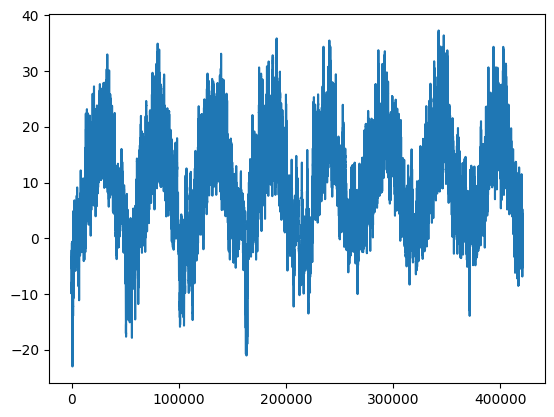

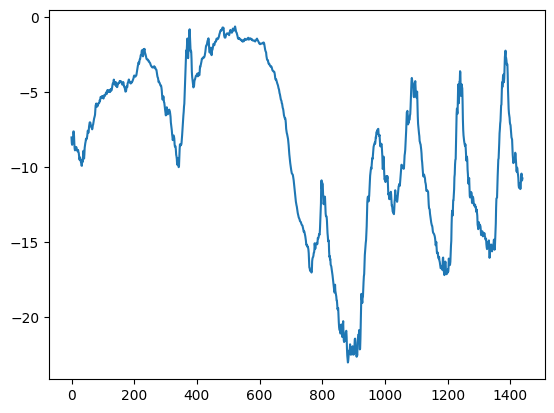

In [10]:
# Plot and see
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

plt.plot(range(len(temperature)),
         temperature); plt.show()

plt.plot(range(1440), temperature[:1440]); plt.show()

In [11]:
# Data train-val-test split
n = len(raw_data)
num_train_samples = int(0.5 * n)
num_val_samples = int(0.25 * n)
num_test_samples = n - num_train_samples - num_val_samples
print(num_train_samples, num_val_samples, num_test_samples)

# Data normalization
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

210225 105112 105114


In [12]:
# Data preparation
from tensorflow.keras.utils import timeseries_dataset_from_array
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)
val_dataset = timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)
test_dataset = timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

In [14]:
# Checking the shape of data
for samples, targets in train_dataset:
    print("samples shape:", samples.shape) # samples shape: (256, 120, 14)
    print("targets shape:", targets.shape) # targets shape: (256,)
    break
    
# Create and train a model
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from tensorflow.keras.models import load_model
inputs = Input(shape=(sequence_length, raw_data.shape[-1]))
x = SimpleRNN(16)(inputs)
outputs = Dense(1)(x)
model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

samples shape: (256, 120, 14)
targets shape: (256,)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 120, 14)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
h = model.fit(train_dataset, epochs=10, validation_data=val_dataset)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 36s 40ms/step - loss: 71.9916 - mae: 6.6271 - val_loss: 16.5948 - val_mae: 2.9969
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 135s 164ms/step - loss: 14.8194 - mae: 2.9286 - val_loss: 10.9843 - val_mae: 2.5152
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 116s 141ms/step - loss: 11.7196 - mae: 2.6525 - val_loss: 9.7313 - val_mae: 2.4060
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 212s 219ms/step - loss: 10.9425 - mae: 2.5769 - val_loss: 9.3536 - val_mae: 2.3729
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 233s 258ms/step - loss: 10.6143 - mae: 2.5431 - val_loss: 9.2053 - val_mae: 2.3624
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - loss: 10.4275 - mae: 2.5227 - val_loss: 9.1325 - val_mae: 2.3533
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 117s 143ms/step - loss: 10.3073 - mae: 2.5076 - val_loss: 9.0155 - val_mae: 2.3355
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 126s 153ms/step - loss: 10.2349 - mae: 2.4991 - val_loss: 8.9812 - val_mae: 2.3330
Epoch 9/10
819/819

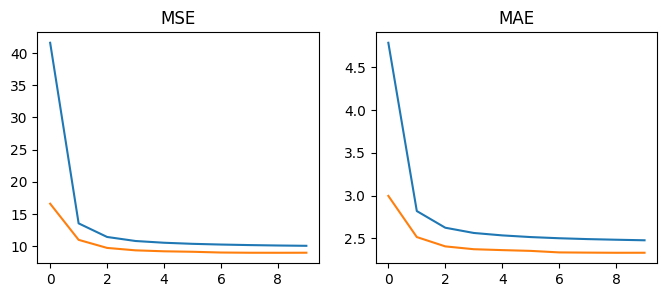

In [19]:
plt.figure(figsize=(8,3))

plt.subplot(121)
plt.plot(h.epoch,h.history["loss"])
plt.plot(h.epoch,h.history["val_loss"])
plt.title("MSE")
plt.subplot(122)
plt.plot(h.epoch,h.history["mae"])
plt.plot(h.epoch,h.history["val_mae"])
plt.title("MAE")

plt.show()